In [110]:
import pandas as pd 
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns


In [111]:
conn = sqlite3.connect("retail.db")

In [112]:

query=""" 
select count(*) as total_rows,
    count(distinct CustomerID) as customers,
    count(distinct StockCode) as products,
    min(InvoiceDate) as date_min,
    max(InvoiceDate) as date_max,
    round(sum(Revenue)) as total_revenue
from transactions;
"""

df=pd.read_sql(query,conn)
df

,total_rows,customers,products,date_min,date_max,total_revenue
0,396470,4334,3660,2010-12-01 08:26:00,2011-12-09 12:50:00,8767753.0


In [113]:
query="""  
select strftime('%Y-%m', InvoiceDate) as month,
    count(distinct InvoiceNo) as orders,
    count(distinct CustomerID) as customers,
    round(sum(revenue),2) as revenue
from transactions
group by strftime('%Y-%m', InvoiceDate)
order by month;
"""



m_df=pd.read_sql(query,conn)

m_df['month'] = pd.to_datetime(m_df['month'])
print(m_df.info())

m_df


<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   month      13 non-null     datetime64[us]
 1   orders     13 non-null     int64         
 2   customers  13 non-null     int64         
 3   revenue    13 non-null     float64       
dtypes: datetime64[us](1), float64(1), int64(2)
memory usage: 548.0 bytes
None


,month,orders,customers,revenue
0,2010-12-01,1395,884,568040.72
1,2011-01-01,983,739,564226.64
2,2011-02-01,992,757,443546.02
3,2011-03-01,1312,973,585262.85
4,2011-04-01,1139,853,455666.91
5,2011-05-01,1544,1054,660917.90
6,2011-06-01,1390,990,654932.56
7,2011-07-01,1321,946,593231.90
8,2011-08-01,1268,933,637157.24
9,2011-09-01,1740,1259,941800.81


In [114]:
print(m_df['month'].min())
print(m_df['month'].max())
print(m_df)

2010-12-01 00:00:00
2011-12-01 00:00:00
        month  orders  customers     revenue
0  2010-12-01    1395        884   568040.72
1  2011-01-01     983        739   564226.64
2  2011-02-01     992        757   443546.02
3  2011-03-01    1312        973   585262.85
4  2011-04-01    1139        853   455666.91
5  2011-05-01    1544       1054   660917.90
6  2011-06-01    1390        990   654932.56
7  2011-07-01    1321        946   593231.90
8  2011-08-01    1268        933   637157.24
9  2011-09-01    1740       1259   941800.81
10 2011-10-01    1903       1361  1006342.90
11 2011-11-01    2642       1660  1143245.77
12 2011-12-01     776        614   513380.43


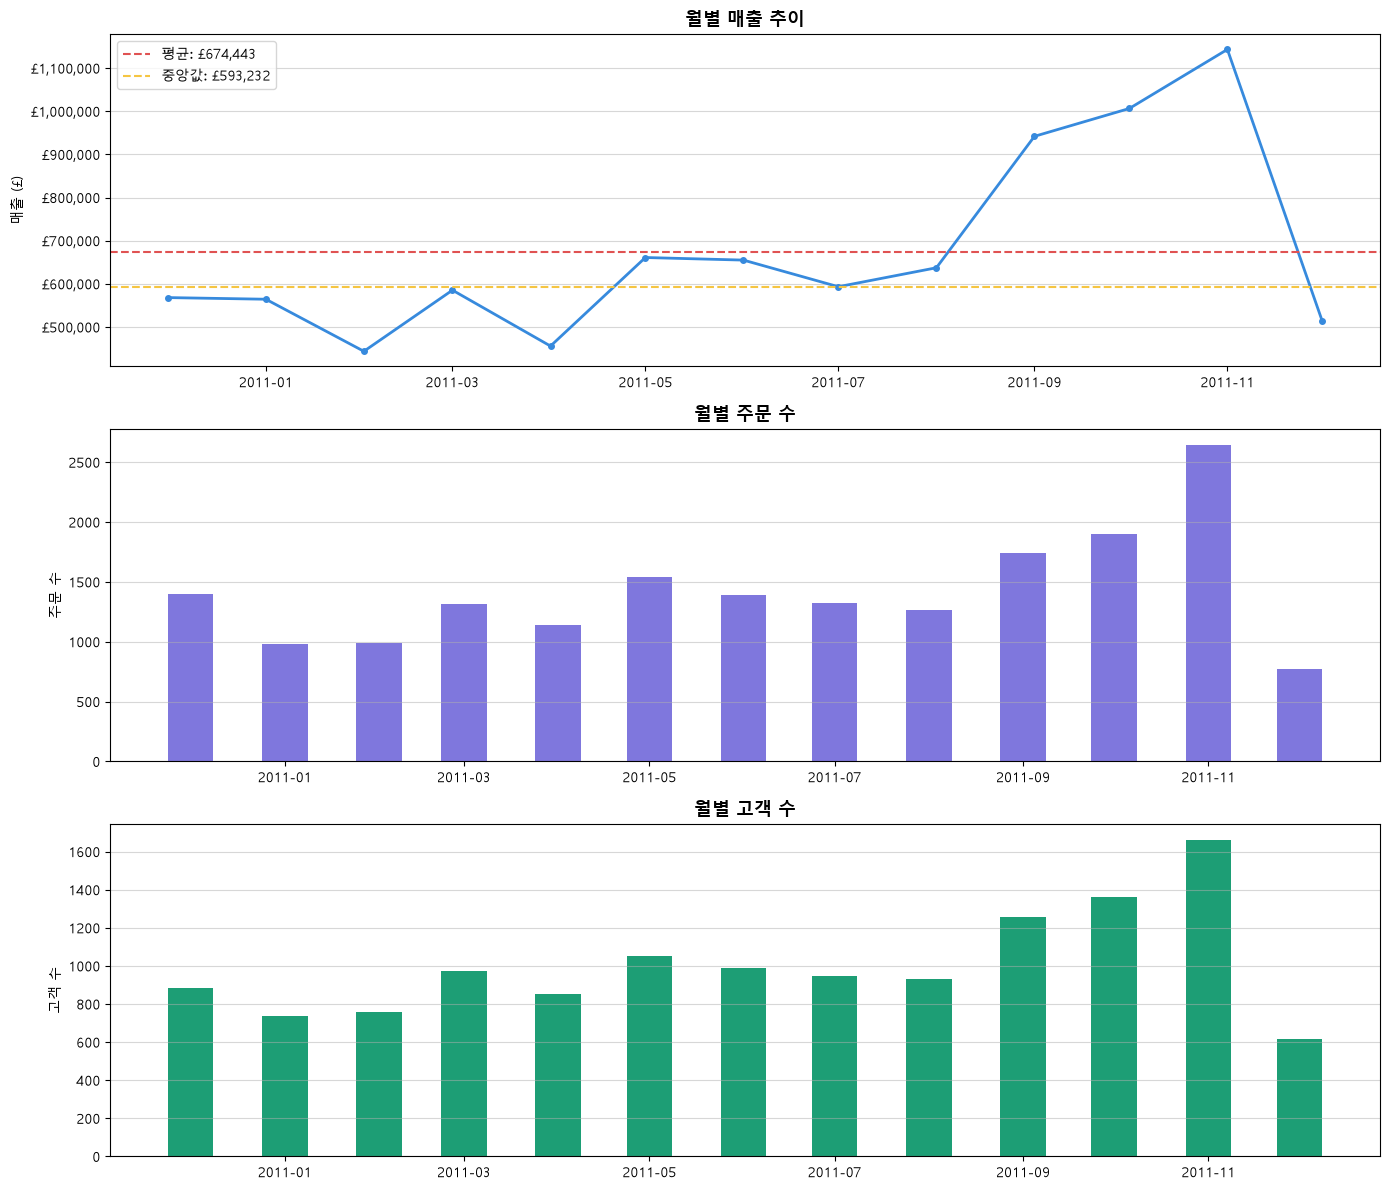

그래프 저장 완료 (imgs/monthly_revenue.png)


In [115]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
plt.rcParams['axes.unicode_minus'] = False



df = m_df.copy()
df['month'] = pd.to_datetime(df['month'])
df = df.sort_values('month')



fig, axes = plt.subplots(3, 1, figsize=(14, 12))



avg_revenue = df['revenue'].mean()
med_revenue = df['revenue'].median()

axes[0].plot(
    df['month'],
    df['revenue'],
    color='#378ADD',
    linewidth=2,
    marker='o',
    markersize=4
)

axes[0].axhline(
    y=avg_revenue,
    color='#E05252',
    linewidth=1.5,
    linestyle='--',
    label=f'평균: £{avg_revenue:,.0f}'
)

axes[0].axhline(
    y=med_revenue,
    color='#F5C542',
    linewidth=1.5,
    linestyle='--',
    label=f'중앙값: £{med_revenue:,.0f}'
)

axes[0].set_title('월별 매출 추이', fontsize=13, fontweight='bold')
axes[0].set_ylabel('매출 (£)')
axes[0].grid(axis='y', alpha=0.5)
axes[0].legend()

axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)
axes[1].bar(
    df['month'],
    df['orders'],
    color='#7F77DD',
    width=15
)

axes[1].set_title('월별 주문 수', fontsize=13, fontweight='bold')
axes[1].set_ylabel('주문 수')
axes[1].grid(axis='y', alpha=0.5)


axes[2].bar(
    df['month'],
    df['customers'],
    color='#1D9E75',
    width=15
)

axes[2].set_title('월별 고객 수', fontsize=13, fontweight='bold')
axes[2].set_ylabel('고객 수')
axes[2].grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.savefig('imgs/monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

print('그래프 저장 완료 (imgs/monthly_revenue.png)')

In [116]:
query=""" 
pragma table_info(transactions)
"""

df=pd.read_sql(query,conn)
df

,cid,name,type,notnull,dflt_value,pk
0,0,InvoiceNo,TEXT,0,None,0
1,1,StockCode,TEXT,0,None,0
2,2,Description,TEXT,0,None,0
3,3,Quantity,INTEGER,0,None,0
4,4,InvoiceDate,TIMESTAMP,0,None,0
5,5,UnitPrice,REAL,0,None,0
6,6,CustomerID,INTEGER,0,None,0
7,7,Country,TEXT,0,None,0
8,8,Revenue,REAL,0,None,0


In [117]:
query=""" 
with cte as (
select StockCode,
    Description,
    count(distinct InvoiceNo) as orders,
    sum(Quantity) as total_quantity,
    round(sum(Revenue),2) as total_revenue,
    Rank() over(order by sum(Revenue) desc) as rank_revenue
from transactions
group by StockCode, Description
)
select* from cte 
where rank_revenue <=20
"""

df_prod=pd.read_sql(query,conn)
df_prod

,StockCode,Description,orders,total_quantity,total_revenue,rank_revenue
0,23843,"PAPER CRAFT , LITTLE BIRDIE",1,80995,168469.60,1
1,22423,REGENCY CAKESTAND 3 TIER,1703,12402,142592.95,2
2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1971,36725,100448.15,3
3,85099B,JUMBO BAG RED RETROSPOT,1600,46181,85220.78,4
4,23166,MEDIUM CERAMIC TOP STORAGE JAR,195,77916,81416.73,5
5,47566,PARTY BUNTING,1379,15291,68844.33,6
6,84879,ASSORTED COLOUR BIRD ORNAMENT,1375,35362,56580.34,7
7,23084,RABBIT NIGHT LIGHT,801,27202,51346.20,8
8,79321,CHILLI LIGHTS,519,9650,46286.51,9
9,22086,PAPER CHAIN KIT 50'S CHRISTMAS,980,15617,42660.83,10


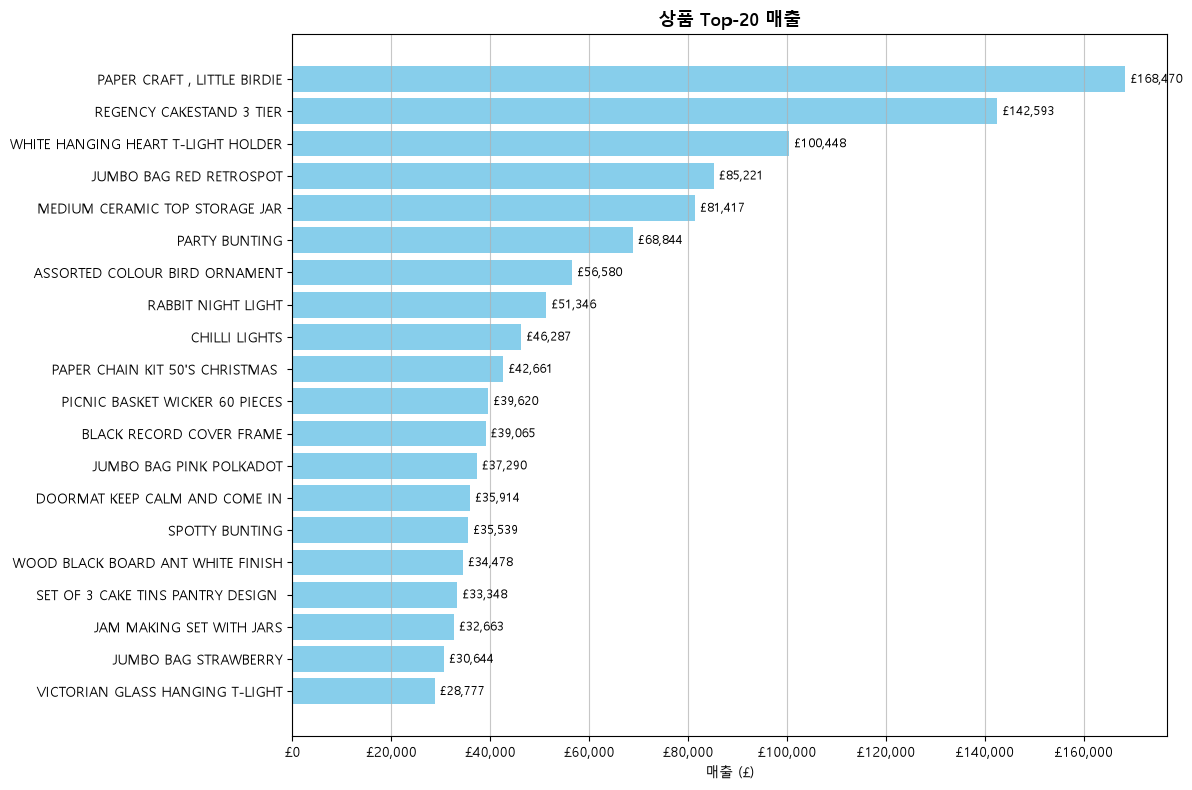

In [118]:
fig, ax = plt.subplots(figsize=(12,8))
bars = ax.barh(
    df_prod["Description"],
    df_prod["total_revenue"],
    color='skyblue'
)
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 1000,
        bar.get_y() + bar.get_height() / 2,
        f'£{width:,.0f}',
        va='center', fontsize=9
    )
ax.set_title('상품 Тоp-20 매출', fontsize=13, fontweight='bold')
ax.set_xlabel('매출 (£)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _:f'£{x:,.0f}'))
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.7)

plt.tight_layout()
plt.savefig('imgs/top_products.png', dpi=150, bbox_inches='tight')
plt.show()

In [119]:
query=""" 
with cte as (
    select
        "CustomerID",
        count(distinct "InvoiceNo") as orders,
        sum("Revenue") as total_revenue,
        sum(sum("Revenue")) over() as total_all_revenue,
        avg("Revenue") as avg_order_value,
        min("InvoiceDate") as first_purchase,
        max("InvoiceDate") as last_purchase,
        rank() over(order by sum("Revenue") DESC) as revenue_rank
    from transactions
    group by "CustomerID"
)
select *,
       round(total_revenue * 100.0 / total_all_revenue, 2) as revenue_share_pct
from cte
where revenue_rank <= 20;
"""

df_cust=pd.read_sql(query,conn)

df_cust['first_purchase'] = pd.to_datetime(df_cust['first_purchase'])
df_cust['last_purchase'] = pd.to_datetime(df_cust['last_purchase'])

print(df_cust.info())
df_cust

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   CustomerID         20 non-null     int64         
 1   orders             20 non-null     int64         
 2   total_revenue      20 non-null     float64       
 3   total_all_revenue  20 non-null     float64       
 4   avg_order_value    20 non-null     float64       
 5   first_purchase     20 non-null     datetime64[us]
 6   last_purchase      20 non-null     datetime64[us]
 7   revenue_rank       20 non-null     int64         
 8   revenue_share_pct  20 non-null     float64       
dtypes: datetime64[us](2), float64(4), int64(3)
memory usage: 1.5 KB
None


,CustomerID,orders,total_revenue,total_all_revenue,avg_order_value,first_purchase,last_purchase,revenue_rank,revenue_share_pct
0,14646,72,279138.02,8767752.65,135.503893,2010-12-20 10:09:00,2011-12-08 12:12:00,1,3.18
1,18102,60,259657.30,8767752.65,602.453132,2010-12-07 16:42:00,2011-12-09 11:50:00,2,2.96
2,17450,46,194550.79,8767752.65,577.302047,2010-12-07 09:23:00,2011-12-01 13:29:00,3,2.22
3,16446,2,168472.50,8767752.65,56157.500000,2011-05-18 09:52:00,2011-12-09 09:15:00,4,1.92
4,14911,199,140450.72,8767752.65,24.757751,2010-12-01 14:05:00,2011-12-08 15:54:00,5,1.60
5,12415,20,124564.53,8767752.65,174.704811,2011-01-06 11:12:00,2011-11-15 14:22:00,6,1.42
6,14156,55,117379.63,8767752.65,83.842593,2010-12-03 11:48:00,2011-11-30 10:54:00,7,1.34
7,17511,31,91062.38,8767752.65,94.561142,2010-12-01 10:19:00,2011-12-07 10:12:00,8,1.04
8,12346,1,77183.60,8767752.65,77183.600000,2011-01-18 10:01:00,2011-01-18 10:01:00,9,0.88
9,16029,62,72882.09,8767752.65,302.415311,2010-12-01 09:57:00,2011-11-01 10:27:00,10,0.83


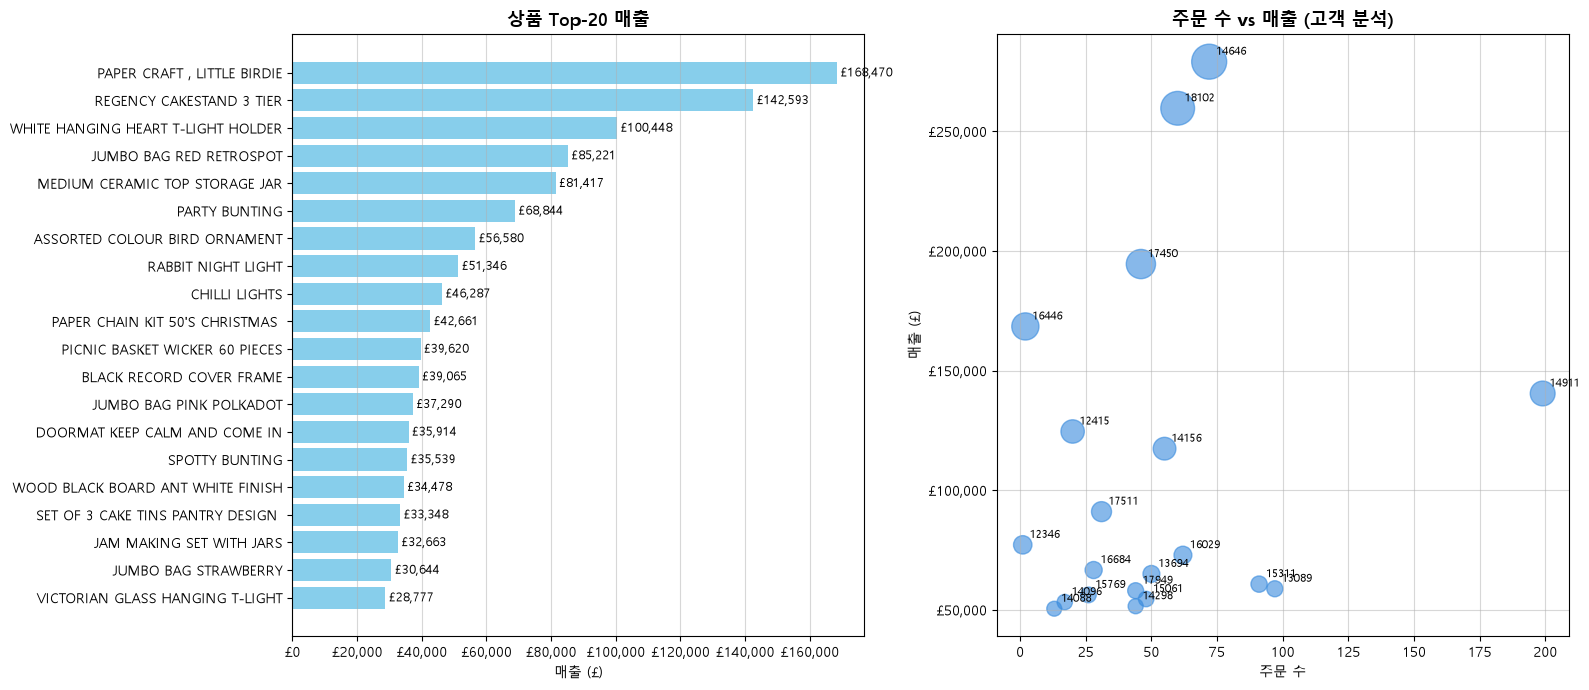

In [120]:
fig, axes = plt.subplots(1, 2, figsize=(16,7))

axes[0].barh(
    df_prod['Description'],
    df_prod['total_revenue'],
    color='skyblue'
)

for i, value in enumerate(df_prod['total_revenue']):
    axes[0].text(
        value + 1000,
        i,
        f'£{value:,.0f}',
        va='center', fontsize=9
    )

axes[0].set_title('상품 Тоp-20 매출', fontsize=13, fontweight='bold')
axes[0].set_xlabel('매출 (£)')

axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)

axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.5)

scatter = axes[1].scatter(
    df_cust['orders'],
    df_cust['total_revenue'],
    s=df_cust['revenue_share_pct'] * 200,
    color='#378ADD',
    alpha=0.6
)

for _, row in df_cust.iterrows():
    axes[1].annotate(
        str(int(row['CustomerID'])),
        (row['orders'], row['total_revenue']),
        fontsize=8,
        xytext=(5, 5),
        textcoords='offset points'
    )

axes[1].set_title('주문 수 vs 매출 (고객 분석)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('매출 (£)')
axes[1].set_xlabel('주문 수')

axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)

axes[1].grid(alpha=0.5)

plt.tight_layout()
plt.savefig('imgs/top_products_customers.png', dpi=150, bbox_inches='tight')
plt.show()

In [122]:
query="""
with cte as (
    select 
        strftime('%Y-%m', InvoiceDate) as month,
        sum(revenue) as revenue
    from transactions
    group by strftime('%Y-%m', InvoiceDate)
)

select
    month,
    revenue,

    round(sum(revenue) over (
        order by month
    ), 2) as cumulative_revenue,

    round(avg(revenue) over (
        order by month
        rows between 2 preceding and current row
    ), 2) as moving_avg_3m

from cte
order by month;
"""

df_cumulative=pd.read_sql(query,conn)
df_cumulative['month']=pd.to_datetime(df_cumulative['month'])
print(df_cumulative.info())
df_cumulative

<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   month               13 non-null     datetime64[us]
 1   revenue             13 non-null     float64       
 2   cumulative_revenue  13 non-null     float64       
 3   moving_avg_3m       13 non-null     float64       
dtypes: datetime64[us](1), float64(3)
memory usage: 548.0 bytes
None


,month,revenue,cumulative_revenue,moving_avg_3m
0,2010-12-01,568040.72,568040.72,568040.72
1,2011-01-01,564226.64,1132267.36,566133.68
2,2011-02-01,443546.02,1575813.38,525271.13
3,2011-03-01,585262.85,2161076.23,531011.84
4,2011-04-01,455666.91,2616743.14,494825.26
5,2011-05-01,660917.90,3277661.04,567282.55
6,2011-06-01,654932.56,3932593.60,590505.79
7,2011-07-01,593231.90,4525825.50,636360.79
8,2011-08-01,637157.24,5162982.74,628440.57
9,2011-09-01,941800.81,6104783.55,724063.32


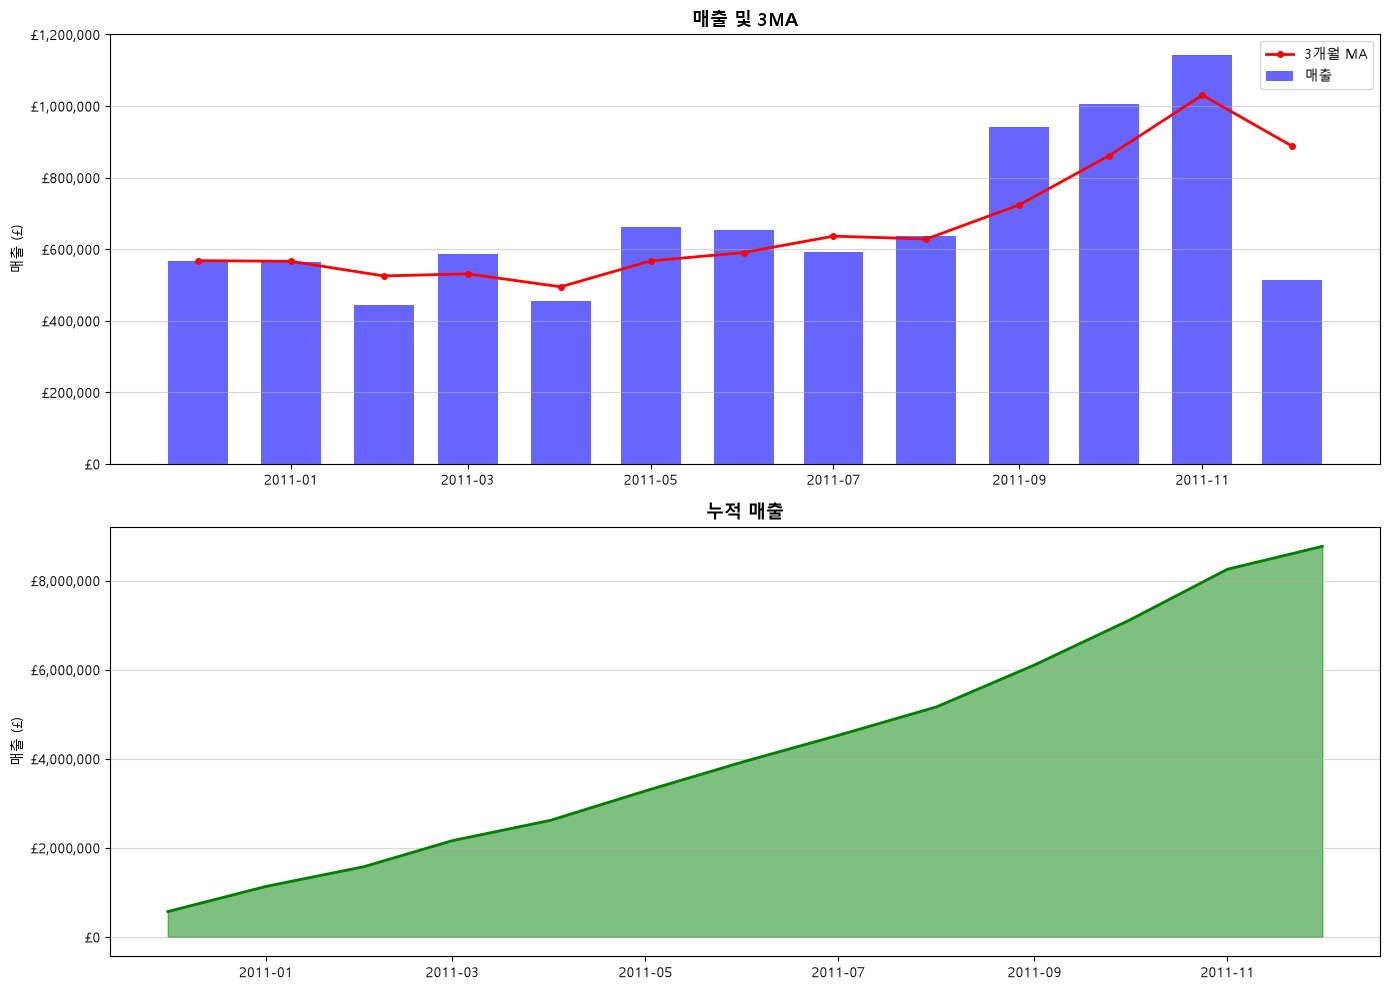

In [123]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))


axes[0].bar(df_cumulative['month'], df_cumulative['revenue'],
            color='blue', width=20, alpha=0.6, label='매출')
axes[0].plot(df_cumulative['month'], df_cumulative['moving_avg_3m'],
             color='red', linewidth=2, marker='o',
             markersize=4, label='3개월 MA')
axes[0].set_title('매출 및 3MA', fontsize=13, fontweight='bold')
axes[0].set_ylabel('매출 (£)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[0].legend()
axes[0].grid(axis='y', alpha=0.5)


axes[1].fill_between(df_cumulative['month'],
                     df_cumulative['cumulative_revenue'],
                     color='green', alpha=0.5, label='누적')
axes[1].plot(df_cumulative['month'], df_cumulative['cumulative_revenue'],
             color='green', linewidth=2)
axes[1].set_title('누적 매출', fontsize=13, fontweight='bold')
axes[1].set_ylabel('매출 (£)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[1].grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.savefig('imgs/cumulative_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

In [124]:
query= """ 
with cte as (
select strftime('%Y-%m', InvoiceDate) as month,
    round(sum(Revenue)) as revenue,
    round(lag(sum(Revenue)) over(order by strftime('%Y-%m', InvoiceDate)), 2) as prev_month_revenue,
    round(lead(sum(Revenue)) over(order by strftime('%Y-%m', InvoiceDate)),2) as next_month_revenue
from transactions
group by strftime('%Y-%m',InvoiceDate) 
order by month)
select *,
round((revenue - prev_month_revenue)*100.0/prev_month_revenue,2) as mom_growth_pct
from cte
"""

df_lag=pd.read_sql(query,conn)

df_lag['month']=pd.to_datetime(df_lag['month'])
print(df_lag.info())
df_lag


<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   month               13 non-null     datetime64[us]
 1   revenue             13 non-null     float64       
 2   prev_month_revenue  12 non-null     float64       
 3   next_month_revenue  12 non-null     float64       
 4   mom_growth_pct      12 non-null     float64       
dtypes: datetime64[us](1), float64(4)
memory usage: 652.0 bytes
None


,month,revenue,prev_month_revenue,next_month_revenue,mom_growth_pct
0,2010-12-01,568041.0,NaN,564226.64,NaN
1,2011-01-01,564227.0,568040.72,443546.02,-0.67
2,2011-02-01,443546.0,564226.64,585262.85,-21.39
3,2011-03-01,585263.0,443546.02,455666.91,31.95
4,2011-04-01,455667.0,585262.85,660917.90,-22.14
5,2011-05-01,660918.0,455666.91,654932.56,45.04
6,2011-06-01,654933.0,660917.90,593231.90,-0.91
7,2011-07-01,593232.0,654932.56,637157.24,-9.42
8,2011-08-01,637157.0,593231.90,941800.81,7.40
9,2011-09-01,941801.0,637157.24,1006342.90,47.81


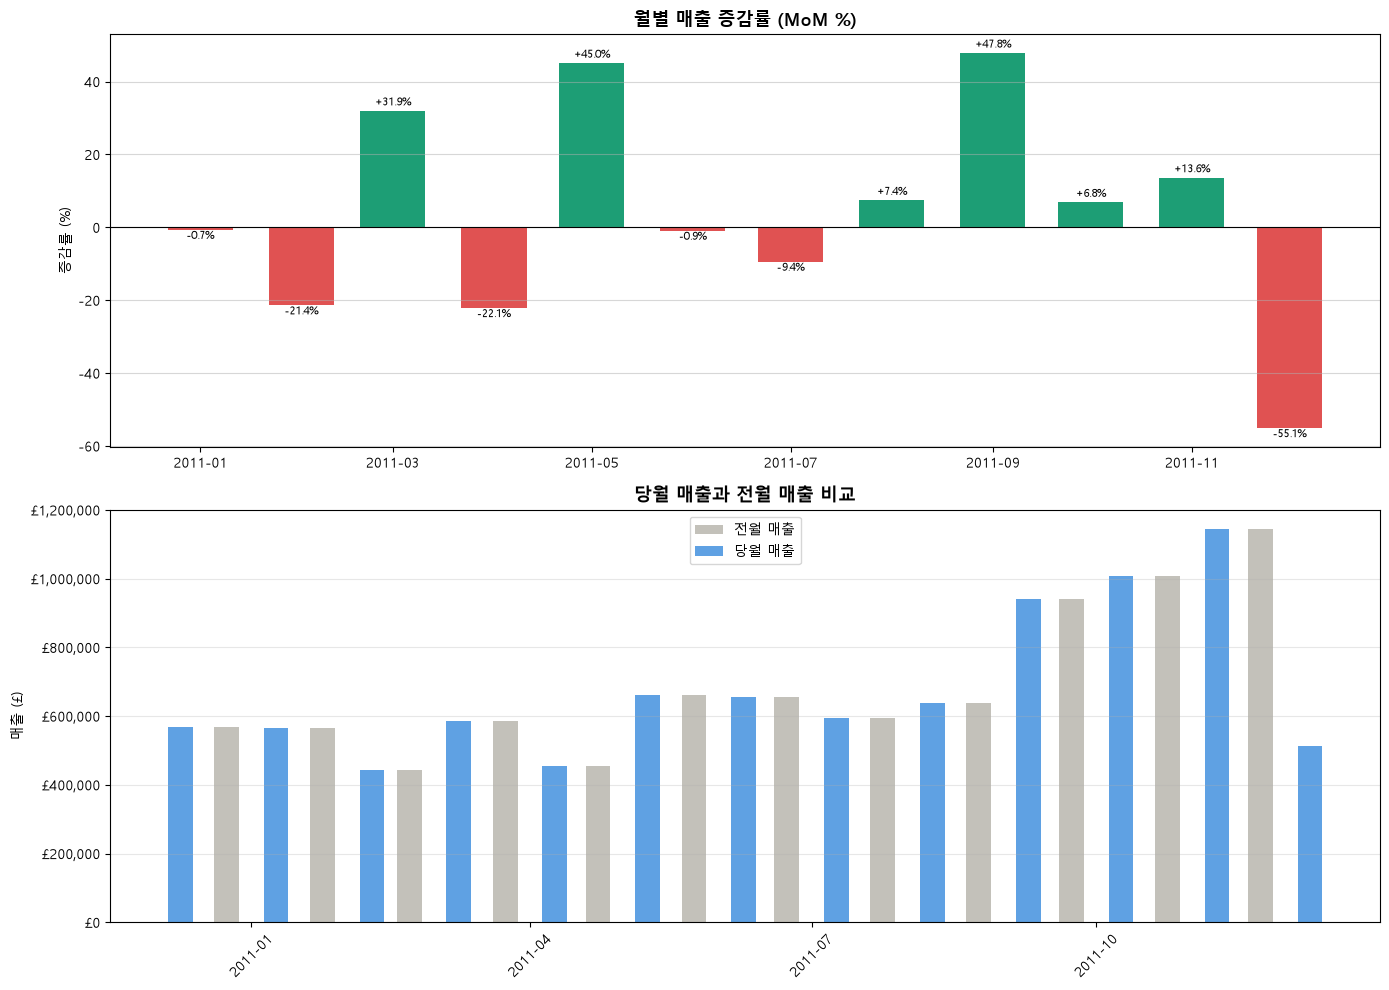

In [ ]:
import matplotlib.dates as mdates
fig, axes = plt.subplots(2, 1, figsize=(14, 10))



color_bars = [
    '#1D9E75' if x >= 0 else '#E05252'
    for x in df_lag['mom_growth_pct'].fillna(0)
]

axes[0].bar(
    df_lag['month'],
    df_lag['mom_growth_pct'],
    color=color_bars,
    width=20
)

axes[0].axhline(y=0, color='black', linewidth=0.8)
axes[0].set_title(
    '월별 매출 증감률 (MoM %)',
    fontsize=13,
    fontweight='bold'
)
axes[0].set_ylabel('증감률 (%)')
axes[0].grid(axis='y', alpha=0.5)


for month, val in zip(
    df_lag['month'],
    df_lag['mom_growth_pct']
):
    if pd.notna(val):
        axes[0].text(
            month,
            val + (1.5 if val >= 0 else -2.5),
            f'{val:+.1f}%',
            ha='center',
            fontsize=8
        )


x = mdates.date2num(df_lag['month'])
bar_width = 8 
shift = 8

axes[1].bar(
    x - shift,
    df_lag['prev_month_revenue'],
    width=bar_width,
    color='#B4B2A9',
    alpha=0.8,
    label='전월 매출'
)

axes[1].bar(
    x + shift,
    df_lag['revenue'],
    width=bar_width,
    color='#378ADD',
    alpha=0.8,
    label='당월 매출'
)


axes[1].xaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%m')
)
axes[1].xaxis.set_major_locator(
    mdates.MonthLocator(interval=3)
)
plt.setp(
    axes[1].xaxis.get_majorticklabels(),
    rotation=45
)

axes[1].set_title(
    '당월 매출과 전월 매출 비교',
    fontsize=13,
    fontweight='bold'
)
axes[1].set_ylabel('매출 (£)')

axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, _: f'£{x:,.0f}'
    )
)

axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(
    'imgs/mom_growth.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()